# Ajuste de modelos candidatos (RMSE, MAE, R²)

Semana 5 - "Modelo base validado".

Este notebook usa `ajuste_modelos.py` para ajustar los tres modelos
candidatos (Newton, Logarítmico, Midilli modificado) contra una curva de
referencia y comparar su desempeño con RMSE, MAE y R².

**De dónde sale la curva de referencia:** el paper de Phitakwinai, Thepa
& Nilnont (2019) no publica una tabla de puntos crudos (tiempo, humedad);
publica los parámetros ya ajustados de 9 modelos bajo 9 condiciones de
secado (su Tabla 2, digitalizada en
`data/reference/phitakwinai_2019_tabla2_parametros.csv`). Para no
depender de una digitalización manual (pixel a pixel) de su figura, que
sería imprecisa, este notebook genera la curva de referencia evaluando
la ecuación Modified-Midilli que los autores ya ajustaron para
**T=60 °C, RH=20 %** (su mejor ajuste individual: r²=0.9997,
RMSE=2.323 %), y ajusta nuestros tres modelos contra esa curva. Ver el
docstring de `ajuste_modelos.py` para el detalle completo de esta
metodología.

In [1]:
import sys
sys.path.append(".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ajuste_modelos import (
    K_REF, N_REF, B_REF, R2_REPORTADO, RMSE_REPORTADO_PCT,
    generar_dataset_referencia, ajustar_todos,
)
from modelo_secado import (
    ParametrosNewton, ParametrosLogaritmico, ParametrosMidilliModificado,
    mr_newton, mr_logaritmico, mr_midilli_modificado,
)

## Dataset de referencia

Se muestrea cada 1 h (igual que el intervalo de registro del paper),
de 0 a 26 h (mismo rango que su Figura 2/3).

In [2]:
t = np.arange(0, 27, 1.0)
ds = generar_dataset_referencia(t)

print(f"Parametros publicados (T=60C, RH=20%): k={K_REF}, n={N_REF}, b={B_REF}")
print(f"r2 reportado por los autores = {R2_REPORTADO}, RMSE reportado = {RMSE_REPORTADO_PCT} %")

pd.DataFrame({"Tiempo (h)": ds["t"], "MR referencia": ds["MR"]}).head(10)

Parametros publicados (T=60C, RH=20%): k=0.121461, n=1.179043, b=0.001722
r2 reportado por los autores = 0.9997, RMSE reportado = 2.323 %


,Tiempo (h),MR referencia
0,0.0,1.000000
1,1.0,0.887348
2,2.0,0.763001
3,3.0,0.646893
4,4.0,0.543372
5,5.0,0.453412
6,6.0,0.376593
7,7.0,0.311865
8,8.0,0.257920
9,9.0,0.213386


## Ajuste de los tres modelos candidatos

`ajustar_todos` hace un ajuste no lineal (mínimos cuadrados,
`scipy.optimize.curve_fit`) de cada modelo contra el dataset de
referencia y calcula R², RMSE y MAE (en espacio de MR, igual que el
paper).

In [3]:
resultados = ajustar_todos(ds["t"], ds["MR"])

filas = []
for nombre, r in resultados.items():
    fila = {"Modelo": nombre, "R2": r.r2, "RMSE": r.rmse, "MAE": r.mae}
    fila.update(r.parametros)
    filas.append(fila)

tabla_resultados = pd.DataFrame(filas).set_index("Modelo")
tabla_resultados

,R2,RMSE,MAE,k,a,c,n,b
Modelo,,,,,,,,
Newton,0.994660,2.026747e-02,1.720069e-02,0.161754,NaN,NaN,NaN,NaN
Logaritmico,0.996678,1.598467e-02,1.338757e-02,0.176830,1.02492,0.017732,NaN,NaN
Midilli_modificado,1.000000,6.129720e-17,3.315249e-17,0.121461,1.00000,NaN,1.179043,0.001722


## Comprobación del pipeline

Como el dataset de referencia se generó con la propia ecuación
Modified-Midilli publicada, el ajuste de nuestro modelo Midilli
modificado debe recuperar (casi) exactamente los parámetros k, n, b
publicados, con R² prácticamente 1. Esto valida que el código de ajuste
está bien implementado antes de usarlo con datos propios (línea base
física u otro dataset) más adelante.

In [4]:
print("Publicados:      k=%.6f  n=%.6f  b=%.6f" % (K_REF, N_REF, B_REF))
midilli = resultados["Midilli_modificado"].parametros
print("Recuperados aqui: k=%.6f  n=%.6f  b=%.6f" % (midilli["k"], midilli["n"], midilli["b"]))

Publicados:      k=0.121461  n=1.179043  b=0.001722
Recuperados aqui: k=0.121461  n=1.179043  b=0.001722


## Comparación visual

Las curvas ajustadas de Newton y Logarítmico se separan visiblemente de
la referencia, mientras que Midilli modificado la reproduce casi
exactamente — coherente con la jerarquía ya anticipada en
`docs/matriz_comparativa_modelos.md`.

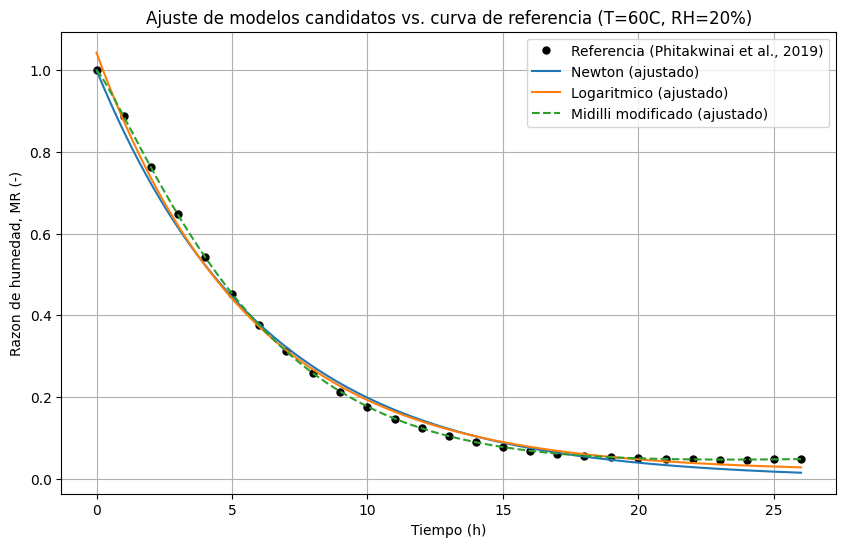

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(ds["t"], ds["MR"], "ko", label="Referencia (Phitakwinai et al., 2019)", markersize=5)

t_fino = np.linspace(0, 26, 200)
plt.plot(t_fino, mr_newton(t_fino, ParametrosNewton(k=resultados["Newton"].parametros["k"])),
         label="Newton (ajustado)")
plt.plot(t_fino, mr_logaritmico(t_fino, ParametrosLogaritmico(**resultados["Logaritmico"].parametros)),
         label="Logaritmico (ajustado)")
plt.plot(t_fino, mr_midilli_modificado(t_fino, ParametrosMidilliModificado(**resultados["Midilli_modificado"].parametros)),
         "--", label="Midilli modificado (ajustado)")

plt.xlabel("Tiempo (h)")
plt.ylabel("Razon de humedad, MR (-)")
plt.title("Ajuste de modelos candidatos vs. curva de referencia (T=60C, RH=20%)")
plt.legend()
plt.grid(True)
plt.show()

## Próximo paso (semana 5)

Con el pipeline de ajuste validado, los siguientes entregables son el
escenario de secado al sol en lazo abierto y la primera línea base
activa, que pueden apoyarse en las ecuaciones generalizadas de la Tabla 3
del paper (`data/reference/phitakwinai_2019_tabla3_ecuaciones_generalizadas.md`)
para predecir k, n, b de Midilli modificado en cualquier combinación de
T/RH dentro de 50-70 °C y 10-30 %, insumo directo para el generador de
perturbaciones ambientales.